# M3: Exploratory Data Analysis and Visualisation
**Role:** Member 3 (M3) · **Rubric item:** Exploratory data analysis and visualisation (3 marks)

**Project:** Early warning for high-pollution days in Delhi: predicting when the **PM2.5-based AQI exceeds 300** and identifying the weather and calendar conditions behind it, so businesses (construction, logistics, schools, event organisers) can plan ahead.

## Objective
Use the team's final daily dataset (`cleaned_final.csv`) to answer five questions:
1. **When** do high-risk days happen (year, month, weekday)?
2. **Which weather conditions** go with them (wind, humidity, rain, temperature, pressure)?
3. **How big is the Diwali effect?**
4. **How persistent is pollution** from one day to the next? This matters for forecasting.
5. **How reliable is the data**, and what are its limitations?

The EDA uses the **same target as the model**: `pm25_target` and `high_risk`, so EDA, models and slides agree. Every chart is saved to `figures/`. The notebook ends with business findings, limitations, and notes for M4 and M5.

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")

# Team's final file: works from the repo root or with the file inside data/
DATA = next(p for p in [Path("cleaned_final.csv"), Path("data/cleaned_final.csv")] if p.exists())
COMPARE = DATA.parent / "target_vs_city_comparison.csv"   # optional: city-mean label kept outside the modelling file
FIG = Path("figures"); FIG.mkdir(exist_ok=True)

# Shared team setting. high_risk is already built from pm25_target >= THRESH, so the EDA never recomputes it;
# THRESH is used here only to draw the line on charts.
# CPCB: AQI 301 starts at PM2.5 121 after rounding to whole numbers, i.e. raw PM2.5 >= 120.5.
THRESH = 120.5
SEVERE = 250.5          # AQI 401+ ("Severe") starts at PM2.5 251 after rounding
PM = "pm25_target"      # the PM2.5 series behind high_risk

# Chart style: one consistent look for every figure
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#d03b3b"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div", ["#1c5cab", "#f0efec", "#c43c3c"])
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 10.5, "axes.titlesize": 12.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlecolor": INK, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "legend.fontsize": 9.5, "figure.dpi": 110,
})

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()

def threshold_line(ax, y=THRESH, label="AQI 300 line (PM2.5 120.5)"):
    ax.axhline(y, color=RED, lw=1.2, ls="--")
    ax.text(ax.get_xlim()[1], y, f"{label} ", color=RED, va="bottom", ha="right", fontsize=9,
            bbox=dict(facecolor=SURFACE, edgecolor="none", alpha=0.85, pad=1.5))

## 2. Load the data and take a first look

In [2]:
df = pd.read_csv(DATA, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df["year"] = df.date.dt.year
print("Shape:", df.shape, "| date range:", df.date.min().date(), "->", df.date.max().date())
print("Duplicate dates:", df.date.duplicated().sum())
leaky = [c for c in ["prev_pm25", "next_pm25", "high_risk_city"] if c in df]
print("Leaky or comparison-only columns present:", leaky or "none")
miss = df.isna().sum(); miss = miss[miss > 0]
display(pd.DataFrame({"missing": miss, "missing_%": (100 * miss / len(df)).round(1)}))

Shape: (3195, 31) | date range: 2018-01-01 -> 2026-09-30
Duplicate dates: 0
Leaky or comparison-only columns present: none


,missing,missing_%
pm25_mean,262,8.2
pm25_median,262,8.2
pm25_ref_station,359,11.2
pm10_mean,1624,50.8
pm10_median,1624,50.8
high_risk,272,8.5
pm25_target,272,8.5


In [3]:
cols = [PM, "pm25_mean", "pm10_mean", "temp_mean", "humidity_mean", "wind_speed_mean",
        "pressure_mean", "precip_sum", "cloud_mean"]
display(df[cols].describe().T.round(1))

,count,mean,std,min,25%,50%,75%,max
pm25_target,2923.0,95.6,79.7,6.2,37.4,67.8,130.0,549.0
pm25_mean,2933.0,97.7,78.4,7.0,40.0,70.5,132.2,525.0
pm10_mean,1571.0,200.3,118.6,14.2,102.7,181.0,278.5,705.5
temp_mean,3195.0,24.8,7.1,6.7,18.8,27.0,30.0,39.2
humidity_mean,3195.0,62.1,19.1,10.2,50.2,65.3,77.7,95.8
wind_speed_mean,3195.0,2.5,0.9,0.6,1.9,2.4,3.0,6.4
pressure_mean,3195.0,983.9,6.5,967.4,978.2,983.9,989.6,998.6
precip_sum,3195.0,2.2,6.9,0.0,0.0,0.0,0.9,122.7
cloud_mean,3195.0,33.0,31.8,0.0,4.1,23.2,55.8,100.0


**Units** (from M1's Open-Meteo request and the OpenAQ files): PM in µg/m³, temperature in °C, humidity and cloud cover in %, wind in m/s, surface pressure in hPa, rain in mm/day.

## 3. The target: PM2.5-based AQI above 300
Official CPCB AQI needs at least 3 pollutants and takes the worst sub-index. Our data has only PM2.5 and PM10, so the team uses a **PM2.5-based AQI**. PM2.5 drives Delhi's winter AQI.

| Column | Meaning |
|---|---|
| `pm25_target` | The PM2.5 series behind the label. It comes from the single long-running **reference station**, or from the **city mean** on days when the reference is missing and at least 10 stations reported. |
| `target_source` | `reference`, `city_fallback` or `missing` |
| `high_risk` | 1 if `pm25_target` ≥ 120.5 µg/m³ (PM2.5-based AQI above 300), otherwise 0. **Used as it is, never recomputed.** |
| `pm25_mean` | The **city mean** across stations. It mixes 1 station in some years with about 30 in others, so it is used here only where labelled "city mean". |

| CPCB category | PM2.5 (µg/m³, rounded) | AQI | In `high_risk`? |
|---|---|---|---|
| Good | 0–30 | 0–50 | no |
| Satisfactory | 31–60 | 51–100 | no |
| Moderate | 61–90 | 101–200 | no |
| Poor | 91–120 | 201–300 | no |
| **Very Poor** | **121–250** | **301–400** | **yes** |
| **Severe** | **251+** | **401–500** | **yes** |

`high_risk` is one yes/no alert covering both **Very Poor** and **Severe**. Some charts below show the two bands separately.

In [4]:
# Check that the label matches its definition (it should, exactly)
t_ok = df.dropna(subset=[PM])
assert ((t_ok[PM] >= THRESH).astype(float) == t_ok.high_risk).all(), "high_risk does not match pm25_target >= THRESH"

bins = [-np.inf, 30.5, 60.5, 90.5, 120.5, 250.5, np.inf]
labels = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
df["category"] = pd.cut(df[PM], bins=bins, labels=labels, right=False)

src = df.target_source.value_counts()
display(pd.DataFrame({"days": src, "share_%": (100 * src / len(df)).round(1)}))
cat = df.category.value_counts().reindex(labels)
display(pd.DataFrame({"days": cat, "share_%": (100 * cat / cat.sum()).round(1)}))
n_known = int(df.high_risk.notna().sum()); n_missing = len(df) - n_known
print(f"high_risk = 1 on {int(df.high_risk.sum())} of {n_known} days with a target ({100 * df.high_risk.mean():.1f}%)")
print(f"Excluded from every risk rate and chart below: {n_missing} of {len(df)} days with no target "
      f"({100 * n_missing / len(df):.1f}%). The target is never imputed.")

,days,share_%
target_source,,
reference,2836,88.8
missing,272,8.5
city_fallback,87,2.7


,days,share_%
category,,
Good,500,17.1
Satisfactory,816,27.9
Moderate,519,17.8
Poor,296,10.1
Very Poor,619,21.2
Severe,173,5.9


high_risk = 1 on 792 of 2923 days with a target (27.1%)
Excluded from every risk rate and chart below: 272 of 3195 days with no target (8.5%). The target is never imputed.


## 3b. Distribution of each variable
Before looking at relationships, check each variable on its own: its shape, its skew, and whether it has extreme values.

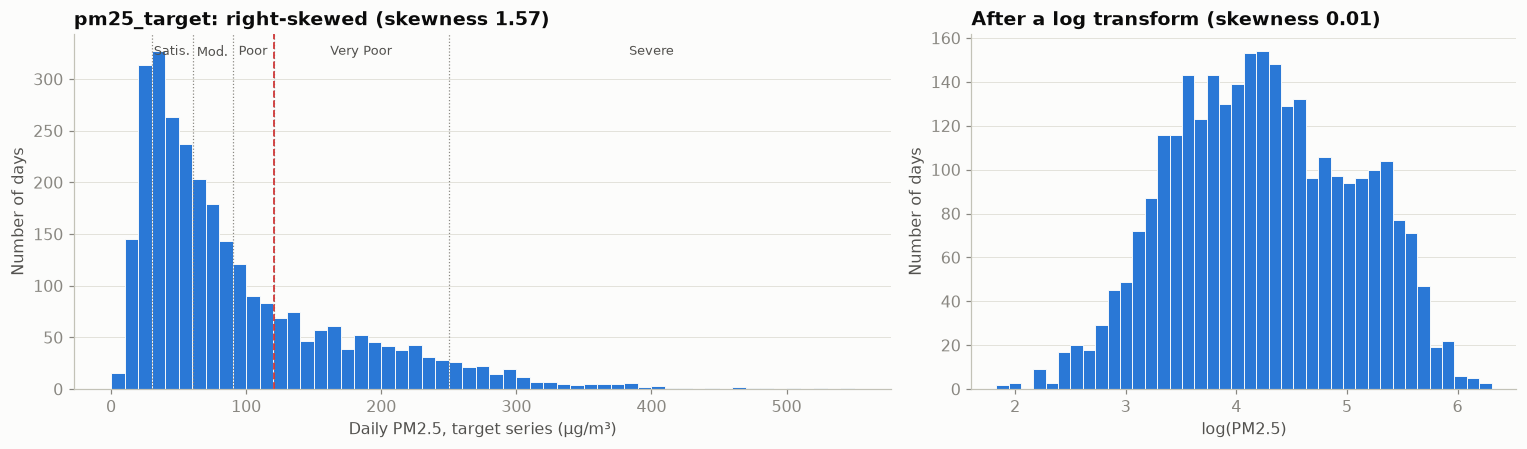

In [5]:
pm = df[PM].dropna()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.5, 1]})
ax[0].hist(pm, bins=np.arange(0, 560, 10), color=BLUE, edgecolor=SURFACE, lw=0.6)
for edge in [30.5, 60.5, 90.5, 120.5, 250.5]:
    ax[0].axvline(edge, color=MUTED, lw=0.8, ls=":")
for x0, x1, name in [(30, 60, "Satis."), (60, 90, "Mod."), (90, 120, "Poor"), (120, 250, "Very Poor"), (250, 550, "Severe")]:
    ax[0].text((x0 + x1) / 2, ax[0].get_ylim()[1] * 0.97, name, ha="center", va="top", color=INK2, fontsize=8.5)
ax[0].axvline(THRESH, color=RED, lw=1.2, ls="--")
ax[0].set_xlabel("Daily PM2.5, target series (µg/m³)"); ax[0].set_ylabel("Number of days")
ax[0].set_title(f"pm25_target: right-skewed (skewness {pm.skew():.2f})")
ax[0].grid(axis="x", visible=False)

ax[1].hist(np.log(pm), bins=40, color=BLUE, edgecolor=SURFACE, lw=0.6)
ax[1].set_xlabel("log(PM2.5)"); ax[1].set_ylabel("Number of days")
ax[1].set_title(f"After a log transform (skewness {np.log(pm).skew():.2f})"); ax[1].grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "00a_pm25_distribution")

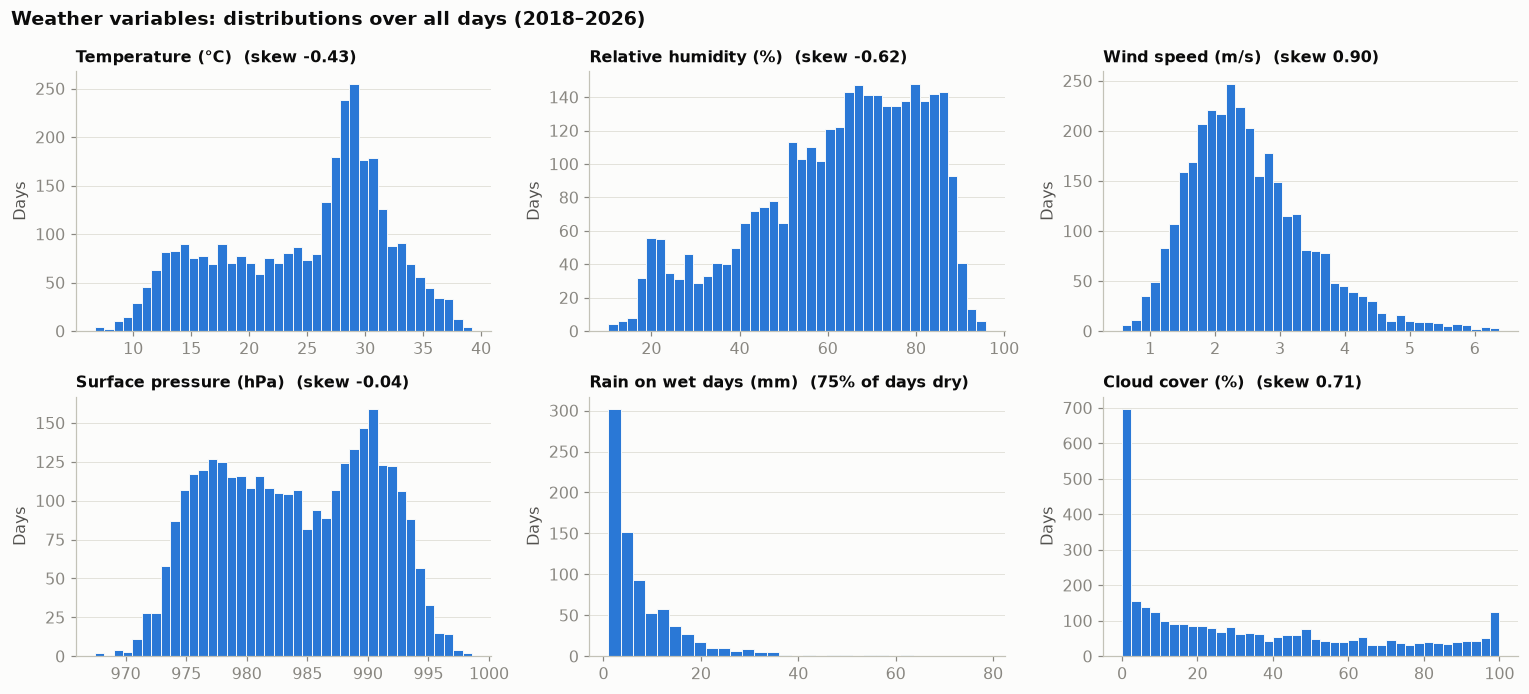

In [6]:
wx = {"temp_mean": "Temperature (°C)", "humidity_mean": "Relative humidity (%)", "wind_speed_mean": "Wind speed (m/s)",
      "pressure_mean": "Surface pressure (hPa)", "precip_sum": "Rain (mm/day)", "cloud_mean": "Cloud cover (%)"}
fig, axes = plt.subplots(2, 3, figsize=(14, 6.4))
for ax, (col, label) in zip(axes.flat, wx.items()):
    x = df[col].dropna()
    if col == "precip_sum":   # most days are dry: show the dry share and the rainy-day distribution separately
        dry = (x < 1).mean()
        ax.hist(x[x >= 1], bins=np.arange(1, 81, 2.5), color=BLUE, edgecolor=SURFACE, lw=0.6)
        ax.set_title(f"Rain on wet days (mm)  ({100 * dry:.0f}% of days dry)", fontsize=10.5)
    else:
        ax.hist(x, bins=40, color=BLUE, edgecolor=SURFACE, lw=0.6)
        ax.set_title(f"{label}  (skew {x.skew():.2f})", fontsize=10.5)
    ax.set_ylabel("Days"); ax.grid(axis="x", visible=False)
fig.suptitle("Weather variables: distributions over all days (2018–2026)", x=0.01, ha="left",
             fontsize=12.5, fontweight="bold", color=INK)
fig.tight_layout(); save(fig, "00b_weather_distributions")

In [7]:
# Extreme values: count points outside 1.5 x IQR (Tukey rule). These are reported, not removed,
# because M2 already removed sensor faults and the remaining extremes are real pollution or weather events.
rows = []
for col in [PM, "pm25_mean", "pm10_mean"] + list(wx):
    x = df[col].dropna(); q1, q3 = x.quantile([0.25, 0.75]); iqr = q3 - q1
    hi = (x > q3 + 1.5 * iqr).sum(); lo = (x < q1 - 1.5 * iqr).sum()
    rows.append((col, len(x), round(x.skew(), 2), int(lo), int(hi), round(100 * (lo + hi) / len(x), 1)))
display(pd.DataFrame(rows, columns=["variable", "days", "skewness", "low_outliers", "high_outliers", "outlier_%"]).set_index("variable"))
top = df.nlargest(5, PM)[["date", PM, "target_source", "days_from_diwali", "wind_speed_mean"]]
print("Five highest PM2.5 days:"); display(top)

,days,skewness,low_outliers,high_outliers,outlier_%
variable,,,,,
pm25_target,2923,1.57,0,130,4.4
pm25_mean,2933,1.51,0,119,4.1
pm10_mean,1571,0.87,0,17,1.1
temp_mean,3195,-0.43,0,0,0.0
humidity_mean,3195,-0.62,0,0,0.0
wind_speed_mean,3195,0.90,0,81,2.5
pressure_mean,3195,-0.04,0,0,0.0
precip_sum,3195,8.31,0,599,18.7
cloud_mean,3195,0.71,0,0,0.0


Five highest PM2.5 days:


,date,pm25_target,target_source,days_from_diwali,wind_speed_mean
1043,2020-11-09,549.0000,reference,-5,1.962083
671,2019-11-03,525.0000,reference,7,2.524583
311,2018-11-08,509.5789,city_fallback,1,1.189167
1044,2020-11-10,487.0000,reference,-4,1.676250
2512,2024-11-17,470.0000,reference,17,1.362500


**What this shows**
- **PM2.5 is strongly right-skewed.** Most days are moderate, but there is a long tail of very bad days, nearly all of them in winter. Medians and box plots are therefore used in the rest of this EDA instead of plain averages. A log transform makes the shape close to symmetric, which is useful if M5 tries a regression model on PM2.5 values.
- The PM2.5 "outliers" by the 1.5 × IQR rule are **real pollution episodes**, not errors. The five worst days are all in November, close to Diwali or on calm days (see the table above). M2 already removed sensor faults, so they are **kept**. They are exactly the days the project is trying to predict.
- **Temperature, humidity and pressure** have no outliers. Temperature and pressure show two humps, one for summer and one for winter, which is the seasonal pattern again.
- **Wind** is mildly right-skewed: mostly light winds, with a few windy days.
- **Rain** is zero on most days, so in models it works better as a "rain day: yes/no" flag than as millimetres.

## 4. How reliable is the data across years?
The monitoring network changes a lot: about 30 stations in some years and one station in 2023–24. This is why the team's target uses a single reference station instead of the city mean.

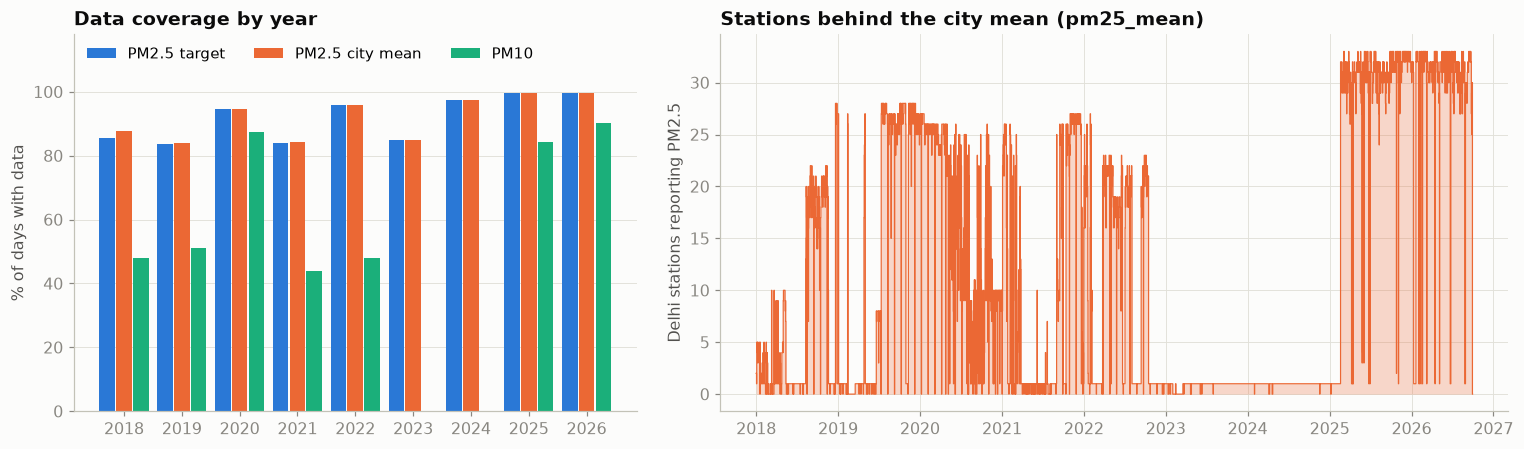

,days,target,city,pm10,target_%,city_%,pm10_%
year,,,,,,,
2018,365,312,320,175,85.5,87.7,47.9
2019,365,306,307,187,83.8,84.1,51.2
2020,366,346,346,320,94.5,94.5,87.4
2021,365,307,308,160,84.1,84.4,43.8
2022,365,350,350,175,95.9,95.9,47.9
2023,365,310,310,0,84.9,84.9,0.0
2024,366,357,357,0,97.5,97.5,0.0
2025,365,363,363,308,99.5,99.5,84.4
2026,273,272,272,246,99.6,99.6,90.1


In [8]:
yr = df.groupby("year").agg(days=("date", "size"), target=(PM, "count"), city=("pm25_mean", "count"), pm10=("pm10_mean", "count"))
for c in ["target", "city", "pm10"]:
    yr[c + "_%"] = (100 * yr[c] / yr.days).round(1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1, 1.4]})
x = np.arange(len(yr)); w = 0.27
ax[0].bar(x - w - 0.02, yr["target_%"], w, color=BLUE, label="PM2.5 target")
ax[0].bar(x, yr["city_%"], w, color=ORANGE, label="PM2.5 city mean")
ax[0].bar(x + w + 0.02, yr["pm10_%"], w, color=AQUA, label="PM10")
ax[0].set_xticks(x, yr.index); ax[0].set_ylim(0, 118); ax[0].set_yticks(range(0, 101, 20))
ax[0].set_ylabel("% of days with data")
ax[0].set_title("Data coverage by year"); ax[0].legend(loc="upper left", ncol=3)
ax[0].grid(axis="x", visible=False)

s = df.set_index("date").pm25_n_stations.fillna(0)
ax[1].fill_between(s.index, s.values, step="mid", color=ORANGE, alpha=0.25, lw=0)
ax[1].plot(s.index, s.values, drawstyle="steps-mid", color=ORANGE, lw=0.8)
ax[1].set_ylabel("Delhi stations reporting PM2.5")
ax[1].set_title("Stations behind the city mean (pm25_mean)")
ax[1].xaxis.set_major_locator(mdates.YearLocator()); ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout(); save(fig, "01_data_coverage")
display(yr)

**What this shows**
- The **PM2.5 target** has data on at least 83% of days in every year. **PM10 is missing for all of 2023 and 2024** and on about half of all days, so PM2.5 is the only pollutant that can be compared across all years.
- The city mean rests on anything from 1 to more than 30 stations, so its level shifts when the network changes. The target series avoids this by using one consistent reference station.

## 5. Trend over time

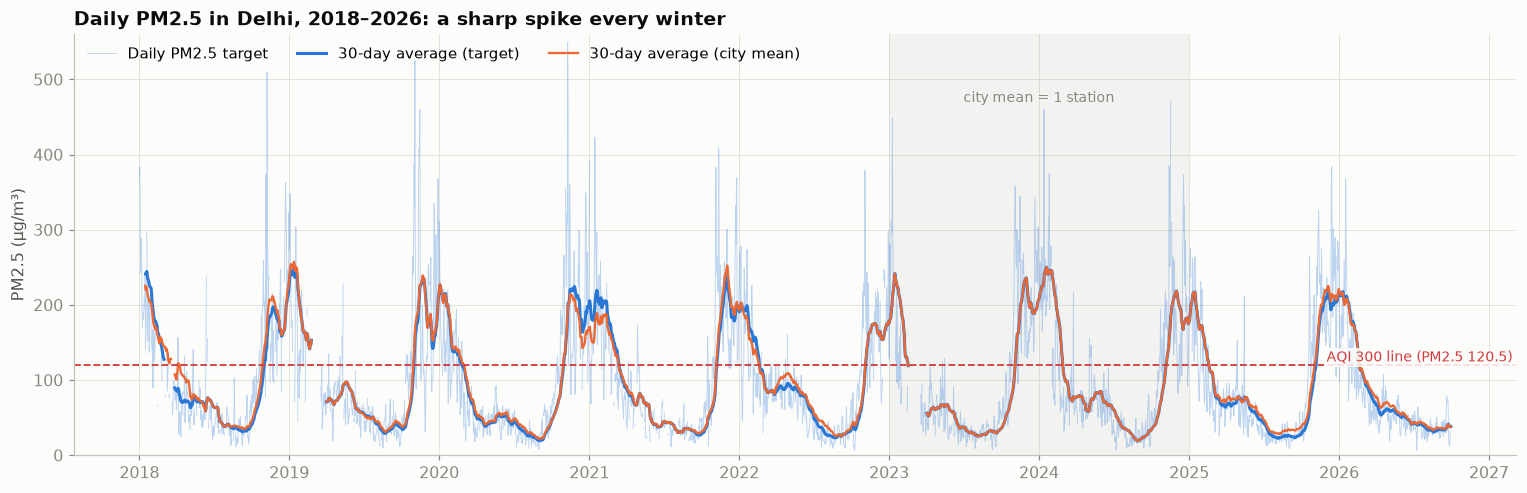

In [9]:
d = df.set_index("date")
fig, ax = plt.subplots(figsize=(14, 4.6))
ax.plot(d.index, d[PM], color=BLUE, lw=0.6, alpha=0.30, label="Daily PM2.5 target")
ax.plot(d.index, d[PM].rolling(30, min_periods=15).mean(), color=BLUE, lw=2, label="30-day average (target)")
ax.plot(d.index, d.pm25_mean.rolling(30, min_periods=15).mean(), color=ORANGE, lw=1.5,
        label="30-day average (city mean)")
ax.axvspan(pd.Timestamp("2023-01-01"), pd.Timestamp("2024-12-31"), color=MUTED, alpha=0.08, lw=0)
ax.text(pd.Timestamp("2024-01-01"), 470, "city mean = 1 station", ha="center", color=MUTED, fontsize=9)
ax.set_ylim(0, 560); ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Daily PM2.5 in Delhi, 2018–2026: a sharp spike every winter")
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
threshold_line(ax)
ax.legend(loc="upper left", ncol=3)
fig.tight_layout(); save(fig, "02_pm25_trend")

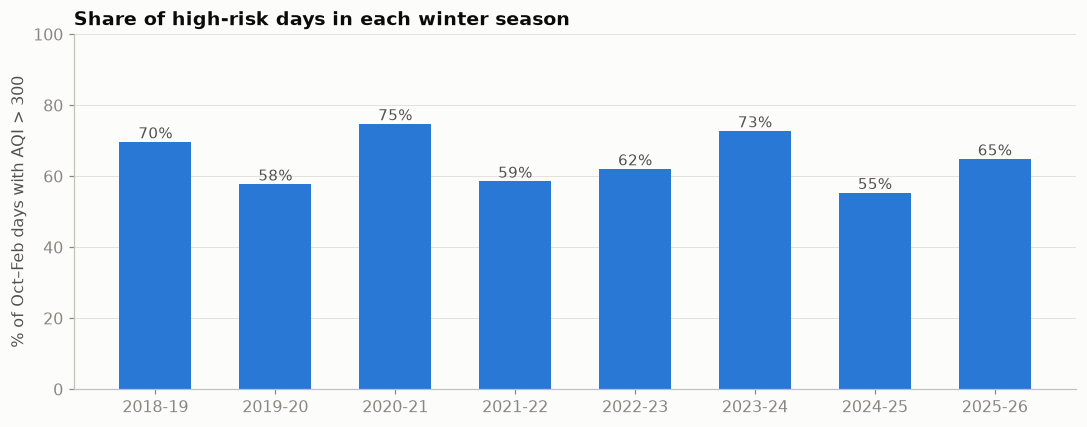

,days_with_target,high_risk_days,severe_days,months_covered,high_risk_%
winter_season,,,,,
2018-19,122,85.0,16,5,69.7
2019-20,147,85.0,23,5,57.8
2020-21,139,104.0,24,5,74.8
2021-22,145,85.0,19,5,58.6
2022-23,116,72.0,10,5,62.1
2023-24,151,110.0,33,5,72.8
2024-25,148,82.0,21,5,55.4
2025-26,151,98.0,21,5,64.9


In [10]:
# High-risk share per winter season (Oct-Feb), so each season stays in one group
df["winter_season"] = np.where(df.month >= 10, df.year.astype(str) + "-" + (df.year + 1).astype(str).str[-2:],
                      np.where(df.month <= 2, (df.year - 1).astype(str) + "-" + df.year.astype(str).str[-2:], None))
ws = (df.dropna(subset=["winter_season"]).groupby("winter_season")
        .agg(days_with_target=("high_risk", "count"), high_risk_days=("high_risk", "sum"),
             severe_days=(PM, lambda s: (s >= SEVERE).sum()),
             months_covered=("month", "nunique")))
ws = ws[ws.months_covered == 5]          # keep only complete Oct-Feb seasons
ws["high_risk_%"] = (100 * ws.high_risk_days / ws.days_with_target).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ws.index, ws["high_risk_%"], color=BLUE, width=0.6)
for i, v in enumerate(ws["high_risk_%"]):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center", color=INK2, fontsize=9.5)
ax.set_ylim(0, 100); ax.set_ylabel("% of Oct–Feb days with AQI > 300")
ax.set_title("Share of high-risk days in each winter season"); ax.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "03_high_days_by_winter")
display(ws)

**What this shows**
- The pattern repeats every year: a sharp rise from October, a peak in November to January, and clean air during the monsoon.
- The target series (blue) and the city mean (orange) follow each other closely, so the seasonal pattern is real and not caused by the changing number of stations.
- Every winter has a large share of high-risk days, with **no clear improvement over time**. The problem comes back each year, which is why a planning tool is useful.

## 6. Seasonal pattern: which months are risky?

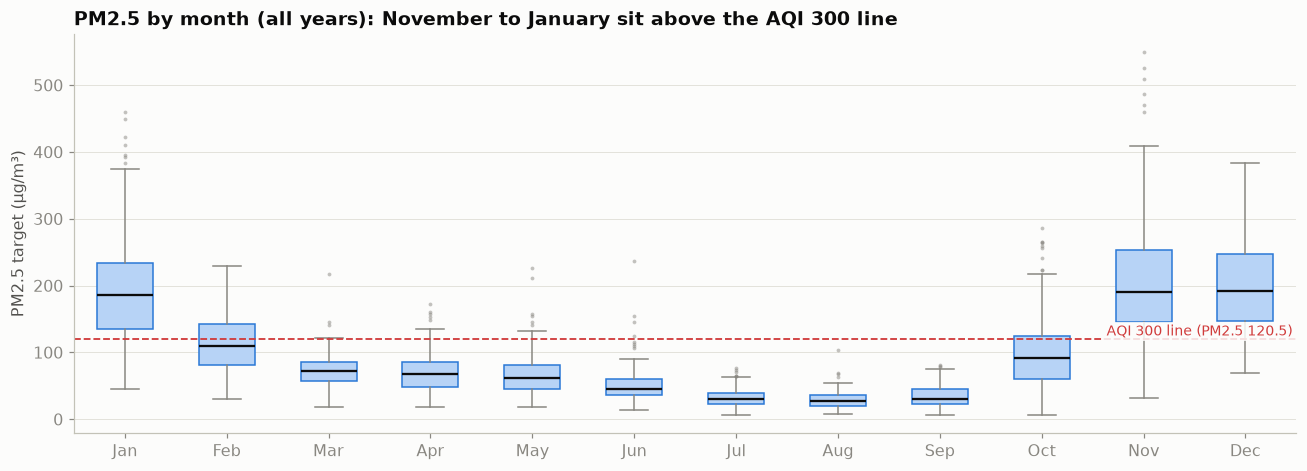

In [11]:
mn = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(12, 4.4))
data = [df.loc[df.month == m, PM].dropna() for m in range(1, 13)]
bp = ax.boxplot(data, patch_artist=True, widths=0.55, showfliers=True,
                medianprops=dict(color=INK, lw=1.5), whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                flierprops=dict(marker="o", ms=2.5, mfc=MUTED, mec="none", alpha=0.5))
for b in bp["boxes"]:
    b.set(facecolor="#b7d3f6", edgecolor=BLUE, lw=1)
ax.set_xticks(range(1, 13), mn); ax.set_ylabel("PM2.5 target (µg/m³)")
ax.set_title("PM2.5 by month (all years): November to January sit above the AQI 300 line")
ax.grid(axis="x", visible=False)
threshold_line(ax)
fig.tight_layout(); save(fig, "04_pm25_by_month")

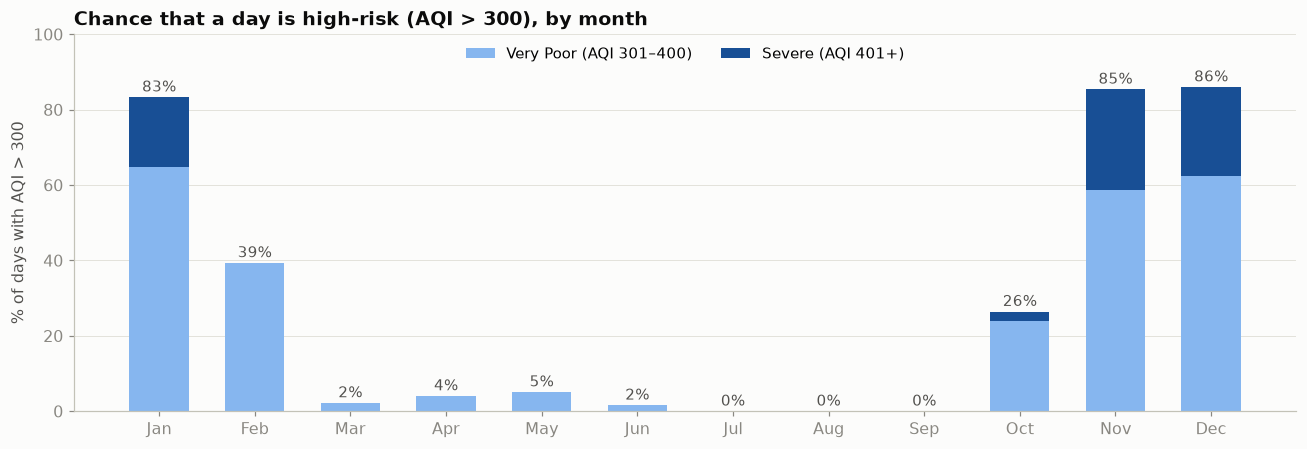

,high_risk,very_poor,severe,median_pm25
month,,,,
Jan,83.3,64.8,18.6,186.0
Feb,39.4,39.4,0.0,109.0
Mar,2.2,2.2,0.0,73.0
Apr,4.1,4.1,0.0,67.0
May,5.1,5.1,0.0,61.0
Jun,1.6,1.6,0.0,46.0
Jul,0.0,0.0,0.0,30.0
Aug,0.0,0.0,0.0,27.0
Sep,0.0,0.0,0.0,31.0


In [12]:
known = df.dropna(subset=["high_risk"])
m = known.groupby("month").agg(high_risk=("high_risk", "mean"),
                               very_poor=("category", lambda s: (s == "Very Poor").mean()),
                               severe=("category", lambda s: (s == "Severe").mean()),
                               median_pm25=(PM, "median"))
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.bar(mn, 100 * m.very_poor, color="#86b6ef", width=0.62, label="Very Poor (AQI 301–400)")
ax.bar(mn, 100 * m.severe, bottom=100 * m.very_poor, color="#184f95", width=0.62, label="Severe (AQI 401+)")
for i, v in enumerate(100 * m.high_risk):
    ax.text(i, v + 1.5, f"{v:.0f}%", ha="center", color=INK2, fontsize=9.5)
ax.set_ylim(0, 100); ax.set_ylabel("% of days with AQI > 300")
ax.set_title("Chance that a day is high-risk (AQI > 300), by month")
ax.legend(loc="upper center", ncol=2); ax.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "05_high_day_share_by_month")
display((100 * m[["high_risk", "very_poor", "severe"]]).round(1).assign(median_pm25=m.median_pm25.round(0)).set_index(pd.Index(mn, name="month")))

This next chart is a **seasonal risk calendar**. Each cell is the share of high-risk days in one month of one year. It is a candidate for the Review 2 dashboard.

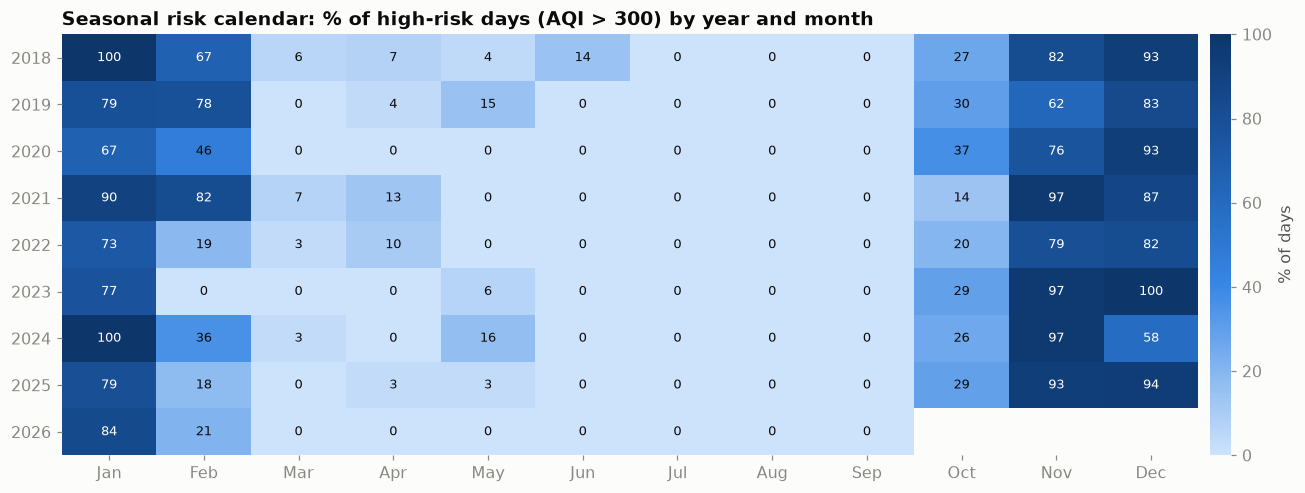

In [13]:
cal = df.pivot_table(index="year", columns="month", values="high_risk", aggfunc="mean") * 100
cal = cal.reindex(columns=range(1, 13))
fig, ax = plt.subplots(figsize=(12, 4.6))
im = ax.imshow(cal.values, cmap=SEQ, vmin=0, vmax=100, aspect="auto")
for i in range(cal.shape[0]):
    for j in range(cal.shape[1]):
        v = cal.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8.5, color="white" if v > 55 else INK)
ax.set_xticks(range(12), mn); ax.set_yticks(range(len(cal)), cal.index)
ax.grid(False); ax.spines[:].set_visible(False)
ax.set_title("Seasonal risk calendar: % of high-risk days (AQI > 300) by year and month")
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01); cb.outline.set_visible(False); cb.set_label("% of days", color=INK2)
fig.tight_layout(); save(fig, "06_risk_calendar")

**What this shows**
- **November, December and January** are high-risk on more than 80% of days, and in those months a large part of the risk is **Severe** (AQI 401+), not just Very Poor. **October** (onset) and **February** (tail) are transition months.
- **July to September** have no high-risk days.
- The calendar looks almost the same every year, so the month alone is a strong signal. That makes a "same month in past years" baseline worth testing (M5).

## 7. Weekly pattern: do weekdays matter?

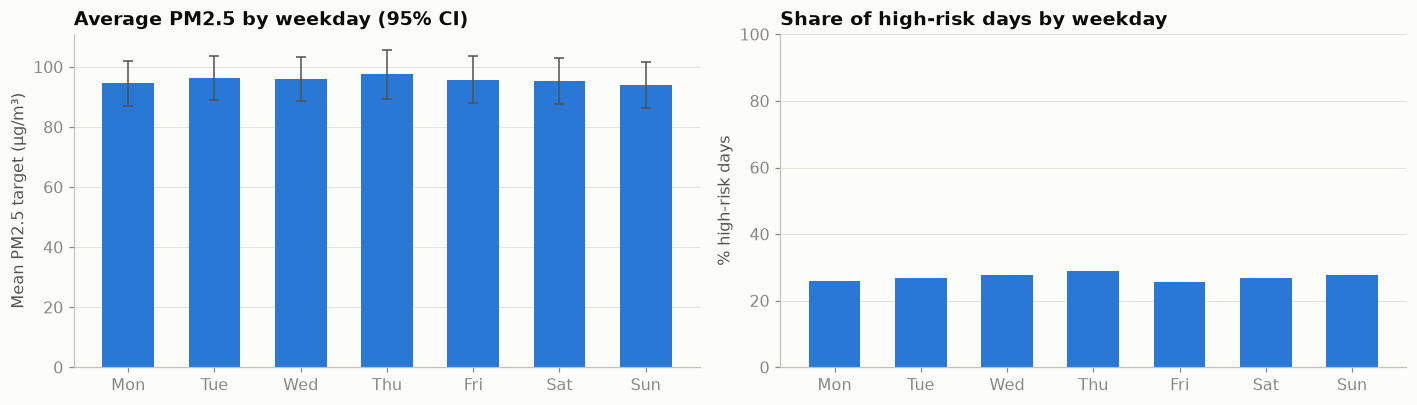

Weekday mean PM2.5 range: 93.9 - 97.5 (spread 3.8% of the overall mean)


In [14]:
dn = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
g = df.groupby("day_of_week")[PM]
mean, se = g.mean(), g.sem()
hs = df.groupby("day_of_week").high_risk.mean() * 100
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].bar(dn, mean, yerr=1.96 * se, color=BLUE, width=0.6, error_kw=dict(ecolor=INK2, lw=1, capsize=3))
ax[0].set_ylabel("Mean PM2.5 target (µg/m³)"); ax[0].set_title("Average PM2.5 by weekday (95% CI)")
ax[1].bar(dn, hs, color=BLUE, width=0.6)
ax[1].set_ylim(0, 100); ax[1].set_ylabel("% high-risk days"); ax[1].set_title("Share of high-risk days by weekday")
for a in ax: a.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "07_weekday_pattern")
print("Weekday mean PM2.5 range:", round(mean.min(), 1), "-", round(mean.max(), 1),
      f"(spread {100 * (mean.max() - mean.min()) / mean.mean():.1f}% of the overall mean)")

**What this shows:** there is **no meaningful weekday effect**. All seven confidence intervals overlap, and the spread between days is under 4%. Daily pollution here depends on season and weather, not on the working week. Day of week is unlikely to help the model much.

## 8. Weather conditions
### 8a. Correlation heatmap
**Spearman** correlation is used because PM2.5 is skewed and the relationships are not straight lines. There are two versions:
- **all year**, which is dominated by the summer-vs-winter difference
- **winter only (Nov–Jan)**, which shows what separates a bad winter day from a less bad one. This is the version that matters for the forecast.

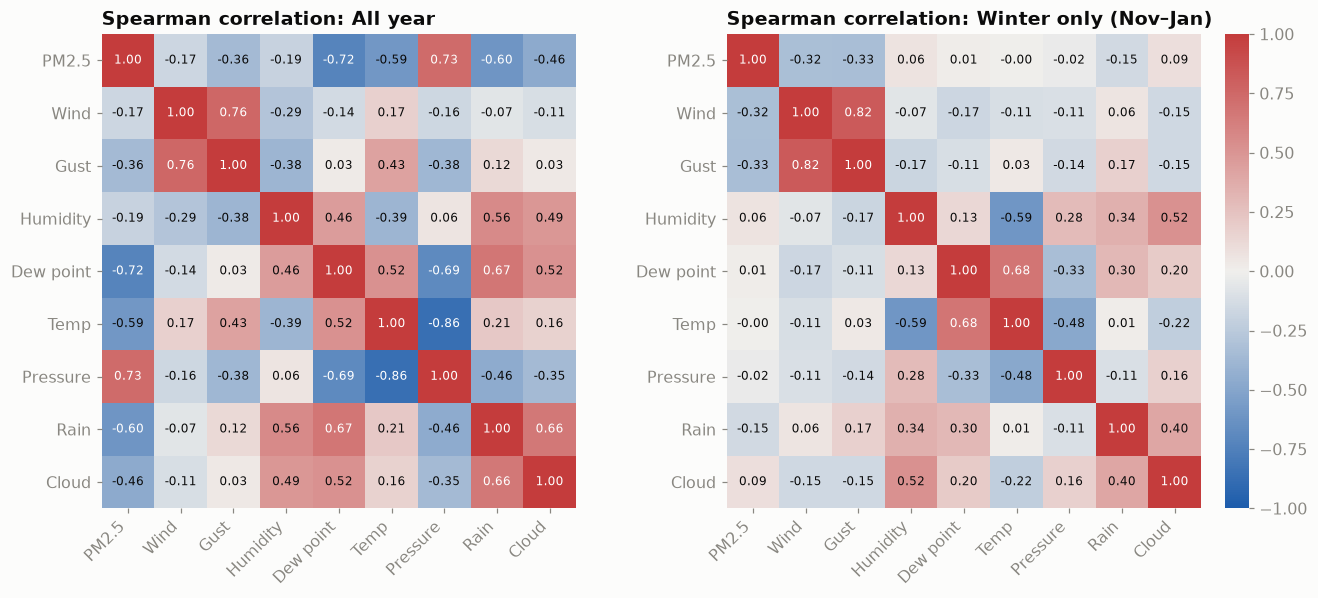

,all_year,winter_Nov_Jan
Gust,-0.36,-0.33
Wind,-0.17,-0.32
Rain,-0.60,-0.15
Pressure,0.73,-0.02
Temp,-0.59,-0.00
Dew point,-0.72,0.01
Humidity,-0.19,0.06
Cloud,-0.46,0.09


In [15]:
wcols = {PM: "PM2.5", "wind_speed_mean": "Wind", "wind_gust_max": "Gust", "humidity_mean": "Humidity",
         "dewpoint_mean": "Dew point", "temp_mean": "Temp", "pressure_mean": "Pressure",
         "precip_sum": "Rain", "cloud_mean": "Cloud"}
winter = df[df.month.isin([11, 12, 1])]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
for ax, (title, sub) in zip(axes, [("All year", df), ("Winter only (Nov–Jan)", winter)]):
    c = sub[list(wcols)].rename(columns=wcols).corr("spearman")
    im = ax.imshow(c.values, cmap=DIV, vmin=-1, vmax=1)
    for i in range(len(c)):
        for j in range(len(c)):
            v = c.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if abs(v) > 0.6 else INK)
    ax.set_xticks(range(len(c)), c.columns, rotation=45, ha="right"); ax.set_yticks(range(len(c)), c.columns)
    ax.grid(False); ax.spines[:].set_visible(False); ax.set_title(f"Spearman correlation: {title}")
cb = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02); cb.outline.set_visible(False)
save(fig, "08_correlation_heatmap")

corr_tbl = pd.DataFrame({
    "all_year": df[list(wcols)].corr("spearman")[PM],
    "winter_Nov_Jan": winter[list(wcols)].corr("spearman")[PM]}).drop(PM).rename(index=wcols).round(2)
display(corr_tbl.sort_values("winter_Nov_Jan"))

**What this shows**
- **All year:** PM2.5 is strongly linked with **high pressure, low temperature, low dew point and little rain**. These all describe the winter season, so the full-year correlations mostly measure "is it winter?".
- **Winter only:** most of those links disappear. **Wind speed** is the clearest weather driver *within* winter: calmer days are dirtier. Humidity and temperature add little once the season is fixed.
- This means the model needs **season (month) and wind** in particular, and the season effect should not be counted twice through temperature and pressure.

### 8b. PM2.5 against wind and humidity (winter days)

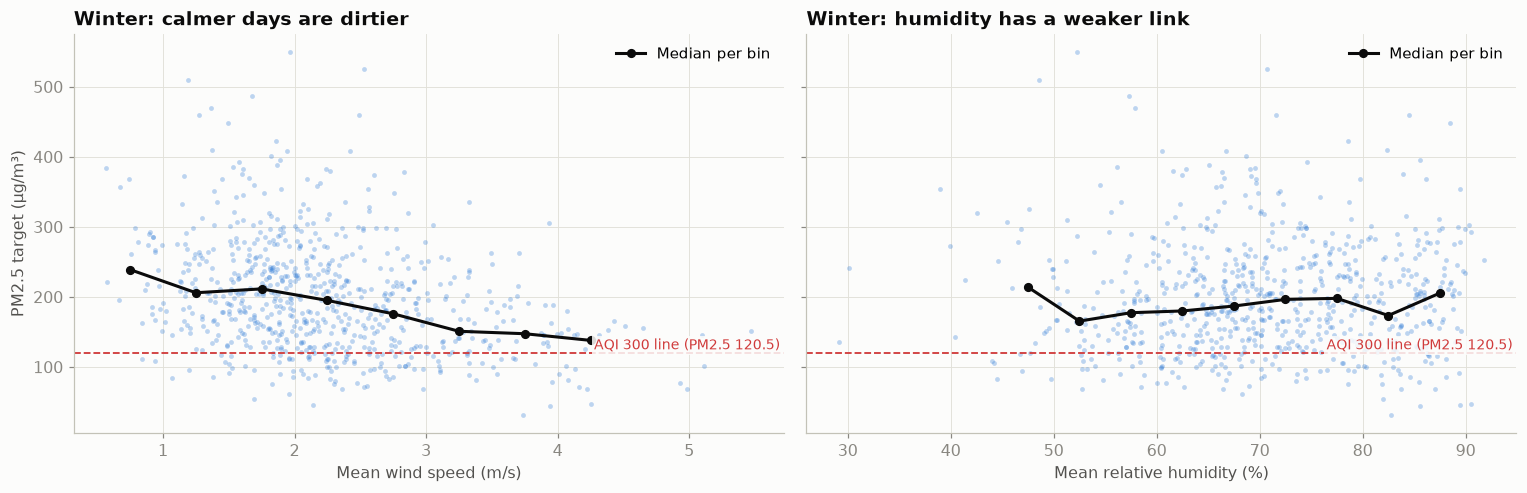

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)
for a, col, unit, step in [(ax[0], "wind_speed_mean", "Mean wind speed (m/s)", 0.5),
                           (ax[1], "humidity_mean", "Mean relative humidity (%)", 5)]:
    sub = winter[[col, PM]].dropna()
    a.scatter(sub[col], sub[PM], s=10, color=BLUE, alpha=0.30, lw=0)
    b = (sub[col] // step) * step + step / 2
    med = sub.groupby(b)[PM].agg(["median", "size"]); med = med[med["size"] >= 15]
    a.plot(med.index, med["median"], color=INK, lw=2, marker="o", ms=5, label="Median per bin")
    a.set_xlabel(unit); a.legend(loc="upper right")
    threshold_line(a)
ax[0].set_ylabel("PM2.5 target (µg/m³)")
ax[0].set_title("Winter: calmer days are dirtier"); ax[1].set_title("Winter: humidity has a weaker link")
fig.tight_layout(); save(fig, "09_pm25_vs_wind_humidity")

### 8c. Which conditions raise the chance of a high-risk day? (Nov–Jan)

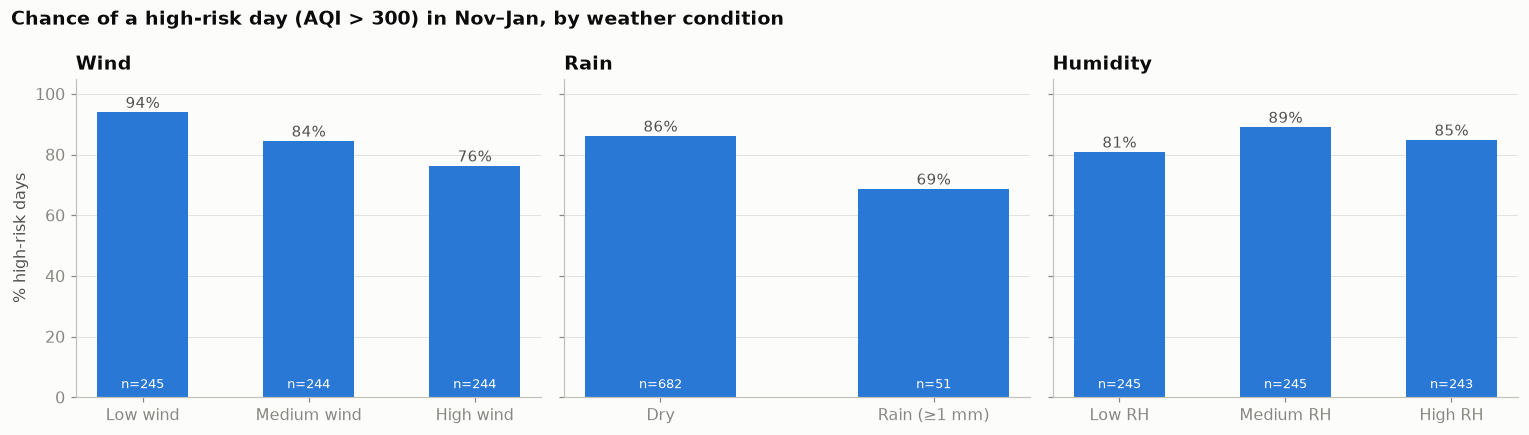

,variable,condition,high_risk_%,days
0,Wind,Low wind,93.9,245
1,Wind,Medium wind,84.4,244
2,Wind,High wind,76.2,244
3,Rain,Dry,86.1,682
4,Rain,Rain (≥1 mm),68.6,51
5,Humidity,Low RH,80.8,245
6,Humidity,Medium RH,89.0,245
7,Humidity,High RH,84.8,243


Wind tercile cut-offs (m/s): [1.83, 2.42]


In [17]:
w = winter.dropna(subset=["high_risk"]).copy()
w["Wind"] = pd.qcut(w.wind_speed_mean, 3, labels=["Low wind", "Medium wind", "High wind"])
w["Rain"] = np.where(w.precip_sum >= 1, "Rain (≥1 mm)", "Dry")
w["Humidity"] = pd.qcut(w.humidity_mean, 3, labels=["Low RH", "Medium RH", "High RH"])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
rows = []
for ax, col in zip(axes, ["Wind", "Rain", "Humidity"]):
    t = w.groupby(col).high_risk.agg(["mean", "size"])
    ax.bar(t.index.astype(str), 100 * t["mean"], color=BLUE, width=0.55)
    for i, (v, n) in enumerate(zip(100 * t["mean"], t["size"])):
        ax.text(i, v + 1.5, f"{v:.0f}%", ha="center", color=INK2, fontsize=9.5)
        ax.text(i, 3, f"n={n}", ha="center", color="white", fontsize=8.5)
    ax.set_ylim(0, 105); ax.set_title(col); ax.grid(axis="x", visible=False)
    rows += [(col, k, round(100 * r["mean"], 1), int(r["size"])) for k, r in t.iterrows()]
axes[0].set_ylabel("% high-risk days")
fig.suptitle("Chance of a high-risk day (AQI > 300) in Nov–Jan, by weather condition", x=0.01, ha="left",
             fontsize=12.5, fontweight="bold", color=INK)
fig.tight_layout(); save(fig, "10_condition_vs_high_share")
display(pd.DataFrame(rows, columns=["variable", "condition", "high_risk_%", "days"]))
print("Wind tercile cut-offs (m/s):", w.wind_speed_mean.quantile([1/3, 2/3]).round(2).tolist())

**What this shows**
- In winter, **low-wind days are high-risk almost every time**. High wind lowers the chance clearly, but it is still well above half.
- **Rain is the other relief signal**: rainy winter days are high-risk less often than dry ones. Winter rain is rare, though, so there are few rain days in the sample (see `n`).
- Humidity makes only a small difference once the season is fixed.
- These grouped conditions (low, medium, high) are the kind of categories the **association-rule** method in Review 2 needs.

## 9. The Diwali effect

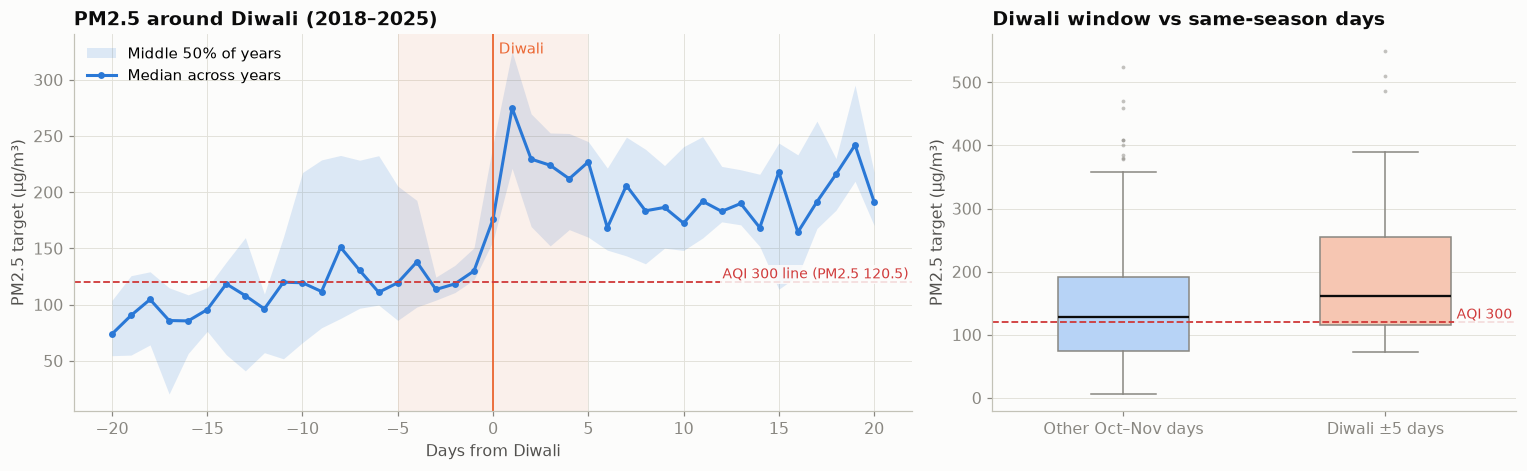

,median_pm25,high_risk_pct,days
Other Oct–Nov days,128.5,52.1,388
Diwali ±5 days,161.0,70.1,87


Median PM2.5, week before Diwali: 125  |  Diwali day to +5 days: 218  (+74%)


In [18]:
win = df[df.days_from_diwali.between(-20, 20)]
g = win.groupby("days_from_diwali")[PM]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw={"width_ratios": [1.6, 1]})
ax[0].fill_between(g.median().index, g.quantile(0.25), g.quantile(0.75), color=BLUE, alpha=0.15, lw=0, label="Middle 50% of years")
ax[0].plot(g.median().index, g.median(), color=BLUE, lw=2, marker="o", ms=3.5, label="Median across years")
ax[0].axvspan(-5, 5, color=ORANGE, alpha=0.08, lw=0)
ax[0].axvline(0, color=ORANGE, lw=1.2)
ax[0].text(0.3, ax[0].get_ylim()[1] * 0.95, "Diwali", color=ORANGE, fontsize=9.5)
ax[0].set_xlabel("Days from Diwali"); ax[0].set_ylabel("PM2.5 target (µg/m³)")
ax[0].set_title("PM2.5 around Diwali (2018–2025)"); ax[0].legend(loc="upper left")
threshold_line(ax[0])

# A fair comparison: festival window vs other days in the SAME months (Oct-Nov)
on = df[df.month.isin([10, 11])].dropna(subset=[PM])
grp = [on.loc[on.is_festival_window == 0, PM], on.loc[on.is_festival_window == 1, PM]]
bp = ax[1].boxplot(grp, patch_artist=True, widths=0.5, medianprops=dict(color=INK, lw=1.5),
                   whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                   flierprops=dict(marker="o", ms=2.5, mfc=MUTED, mec="none", alpha=0.5))
for b, c in zip(bp["boxes"], ["#b7d3f6", "#f6c6b2"]):
    b.set(facecolor=c, edgecolor=MUTED)
ax[1].set_xticks([1, 2], ["Other Oct–Nov days", "Diwali ±5 days"]); ax[1].set_ylabel("PM2.5 target (µg/m³)")
ax[1].set_title("Diwali window vs same-season days"); ax[1].grid(axis="x", visible=False)
threshold_line(ax[1], label="AQI 300")
fig.tight_layout(); save(fig, "11_diwali_effect")

before = df[df.days_from_diwali.between(-7, -1)][PM].median()
after = df[df.days_from_diwali.between(0, 5)][PM].median()
t = on.groupby("is_festival_window").agg(median_pm25=(PM, "median"), high_risk_pct=("high_risk", "mean"), days=("date", "size"))
t["high_risk_pct"] = (100 * t.high_risk_pct).round(1); t.index = ["Other Oct–Nov days", "Diwali ±5 days"]
display(t.round(1))
print(f"Median PM2.5, week before Diwali: {before:.0f}  |  Diwali day to +5 days: {after:.0f}  (+{100 * (after / before - 1):.0f}%)")

**What this shows**
- PM2.5 **jumps on Diwali night and the day after**. It stays high afterwards because Diwali falls just as winter conditions set in.
- Compared with other days in the *same months* (Oct–Nov), the Diwali window has a clearly higher median and a higher share of high-risk days. So it is a real calendar trigger, not just the season.
- Diwali is the only festival in the calendar file (see M2's limitations), so this is a "Diwali effect" rather than a general festival effect.

## 10. Persistence: does today's pollution predict tomorrow's?

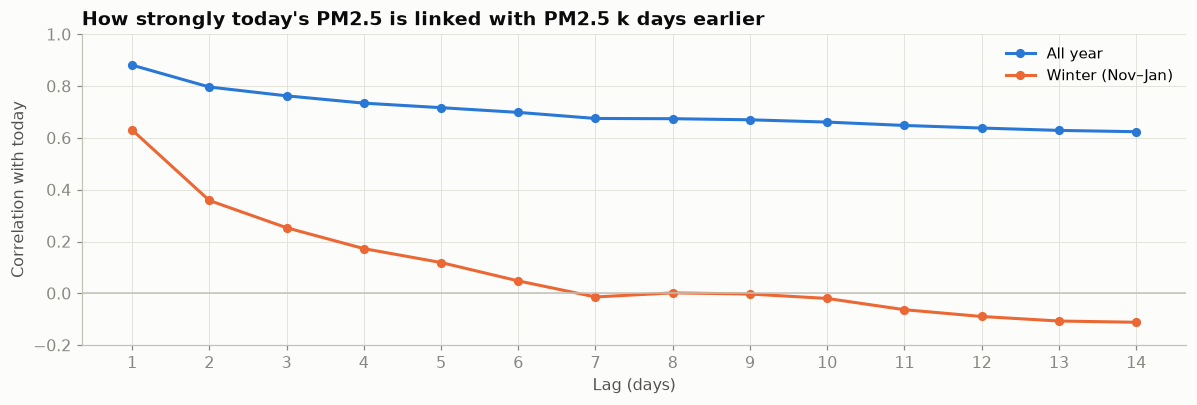

Lag-1 correlation: all year 0.88, winter 0.63, lag-3 all year 0.76
Tomorrow has the same high_risk state as today on 92.7% of day pairs


In [19]:
s = df.set_index("date")[PM]
lags = range(1, 15)
ac_all = [s.corr(s.shift(k)) for k in lags]
sw = s.where(s.index.month.isin([11, 12, 1]))
ac_win = [sw.corr(s.shift(k)) for k in lags]

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(list(lags), ac_all, color=BLUE, lw=2, marker="o", ms=5, label="All year")
ax.plot(list(lags), ac_win, color=ORANGE, lw=2, marker="o", ms=5, label="Winter (Nov–Jan)")
ax.set_ylim(-0.2, 1); ax.axhline(0, color="#c3c2b7", lw=1); ax.set_xticks(list(lags)); ax.set_xlabel("Lag (days)"); ax.set_ylabel("Correlation with today")
ax.set_title("How strongly today's PM2.5 is linked with PM2.5 k days earlier"); ax.legend()
fig.tight_layout(); save(fig, "12_persistence")

# How often does tomorrow keep today's high/not-high state? (only pairs where both days have a target)
h = df.set_index("date").high_risk
same = (h == h.shift(-1))[h.notna() & h.shift(-1).notna()]
print(f"Lag-1 correlation: all year {ac_all[0]:.2f}, winter {ac_win[0]:.2f}, lag-3 all year {ac_all[2]:.2f}")
print(f"Tomorrow has the same high_risk state as today on {100 * same.mean():.1f}% of day pairs")

**What this shows**
- PM2.5 is **highly persistent**: yesterday's value is strongly correlated with today's.
- Over the full year the link stays high even at 2 weeks, because the season itself carries over. **Within winter** it fades within about a week, so the **last 1 to 3 days** carry most of the useful information.
- Tomorrow has the same `high_risk` state as today on about **9 days in 10**. This is why the team plan's baseline ("tomorrow = today") will be **hard to beat**. The model's value has to come from catching the **change days**, when pollution switches from clean to high or back.
- Because the winter link fades quickly, short-term weather (wind, rain) has more room to matter in winter.

## 11. Business findings

In [20]:
mh = (100 * df.groupby("month").high_risk.mean()).round(0)
wt = w.groupby("Wind").high_risk.mean().mul(100).round(0)
rt = w.groupby("Rain").high_risk.mean().mul(100).round(0)
print("KEY NUMBERS FOR THE FINDINGS SLIDE")
print(f"1. High-risk share: Nov {mh[11]:.0f}%, Dec {mh[12]:.0f}%, Jan {mh[1]:.0f}% | Oct {mh[10]:.0f}%, Feb {mh[2]:.0f}% | Jul-Sep {mh[[7,8,9]].max():.0f}%")
print(f"2. Winter wind: low {wt['Low wind']:.0f}% vs high {wt['High wind']:.0f}% | rain {rt['Rain (≥1 mm)']:.0f}% vs dry {rt['Dry']:.0f}%")
print(f"3. Diwali: median PM2.5 {before:.0f} -> {after:.0f} (+{100 * (after / before - 1):.0f}%); "
      f"high-risk share in Oct-Nov {t.loc['Other Oct–Nov days', 'high_risk_pct']:.0f}% -> {t.loc['Diwali ±5 days', 'high_risk_pct']:.0f}%")
print(f"4. Weekday spread: {100 * (mean.max() - mean.min()) / mean.mean():.1f}% of the mean (no weekday effect)")
print(f"5. Persistence: lag-1 correlation {ac_all[0]:.2f}; same state tomorrow {100 * same.mean():.0f}% of day pairs")
print(f"6. High-risk share per winter: {ws['high_risk_%'].min():.0f}%-{ws['high_risk_%'].max():.0f}% (no clear downward trend)")

KEY NUMBERS FOR THE FINDINGS SLIDE
1. High-risk share: Nov 85%, Dec 86%, Jan 83% | Oct 26%, Feb 39% | Jul-Sep 0%
2. Winter wind: low 94% vs high 76% | rain 69% vs dry 86%
3. Diwali: median PM2.5 125 -> 218 (+74%); high-risk share in Oct-Nov 52% -> 70%
4. Weekday spread: 3.8% of the mean (no weekday effect)
5. Persistence: lag-1 correlation 0.88; same state tomorrow 93% of day pairs
6. High-risk share per winter: 55%-75% (no clear downward trend)


| # | What the data shows | What a business can do with it |
|---|---|---|
| 1 | **November to January** are high-risk (AQI > 300) on 83–86% of days. October and February are transition months, and July to September have none. | Schedule outdoor-heavy work (construction phases, outdoor events, school sports) for **March to September**. Build **buffer days** into Nov–Jan plans, and do not commit to tight deadlines then. |
| 2 | In winter, **calm days are high-risk 94% of the time** vs 76% on windy days, and **rain** lowers it from 86% to 69%. | Watch the **wind and rain forecast** in winter. A calm, dry forecast is the warning sign to prepare for GRAP-type restrictions (stagger shifts, switch to indoor work, re-route vehicles). |
| 3 | **Diwali** raises median PM2.5 by about 74% (125 → 218 µg/m³), above the already-high Oct–Nov level. | Treat the **Diwali week** as a high-risk period for deliveries, site work and events, and plan stock and staff before it. |
| 4 | **Weekdays make no difference** (under 4%). | Risk planning can be based on **season and weather**, not the day of the week. |
| 5 | Pollution is **persistent**: tomorrow keeps today's state on about 93% of day pairs. | One high-risk day is a signal to prepare for **several days**, not just one. |
| 6 | Every winter from 2018 to 2026 had 55–75% high-risk days, with **no clear improvement**. | The problem recurs, so building a **forecast and alert system** (this project) is worthwhile year after year. |

## 12. Limitations
Each limitation below is measured, not assumed.

In [21]:
# 1. Days with no target (excluded everywhere above)
print(f"1. No target on {n_missing} of {len(df)} days ({100 * n_missing / len(df):.1f}%); excluded, never imputed.")

# 2. Are high-risk days understated on missing-target days? (city mean exists but had < 10 stations)
mt = df[(df.target_source == "missing") & df.pm25_mean.notna()]
print(f"2. Missing-target days that still have a city mean: {len(mt)}; of these, {int((mt.pm25_mean >= THRESH).sum())} "
      f"have a city mean >= {THRESH} (possible missed high-risk days).")
display(mt.groupby("year").agg(days=("date", "size"), high_city_mean=("pm25_mean", lambda s: int((s >= THRESH).sum()))))

# Sensitivity check: lower the city-mean fallback from 10 stations to 3 (the 10-station version stays the main one)
alt = df[PM].copy()
fb3 = df[PM].isna() & df.pm25_mean.notna() & (df.pm25_n_stations >= 3)
alt[fb3] = df.loc[fb3, "pm25_mean"]
alt_high = (alt >= THRESH).where(alt.notna())
print(f"   Sensitivity (fallback at >= 3 stations): adds {int(fb3.sum())} days; high-risk share "
      f"{100 * df.high_risk.mean():.1f}% -> {100 * alt_high.mean():.1f}%")
sens = pd.DataFrame({"main_%": 100 * df.groupby("month").high_risk.mean(),
                     "fallback3_%": 100 * alt_high.groupby(df.month).mean()}).round(1)
display(sens.T)

# 3. PM2.5-based AQI vs official AQI: days where PM10 alone could push official AQI above 300
x = df[df.pm10_mean.notna() & df[PM].notna()]
pm10_only = ((x.pm10_mean >= 350.5) & (x[PM] < THRESH))
print(f"3. Days where official AQI could exceed 300 through PM10 while PM2.5 does not: {int(pm10_only.sum())} "
      f"of {len(x)} days with both pollutants; by month: {x[pm10_only].month.value_counts().sort_index().to_dict()}")

# 4. Target (reference station) vs city-mean label, from the separate comparison table
if COMPARE.exists():
    cmp_ = pd.read_csv(COMPARE).dropna(subset=["high_risk", "high_risk_city"])
    agree = (cmp_.high_risk == cmp_.high_risk_city).mean()
    print(f"4. high_risk vs high_risk_city agree on {100 * agree:.1f}% of {len(cmp_)} days "
          f"(target 1 / city 0: {int(((cmp_.high_risk == 1) & (cmp_.high_risk_city == 0)).sum())}, "
          f"target 0 / city 1: {int(((cmp_.high_risk == 0) & (cmp_.high_risk_city == 1)).sum())})")

1. No target on 272 of 3195 days (8.5%); excluded, never imputed.
2. Missing-target days that still have a city mean: 10; of these, 7 have a city mean >= 120.5 (possible missed high-risk days).


,days,high_city_mean
year,,
2018,8,7
2019,1,0
2021,1,0


   Sensitivity (fallback at >= 3 stations): adds 9 days; high-risk share 27.1% -> 27.2%


month,1,2,3,4,5,6,7,8,9,10,11,12
main_%,83.3,39.4,2.2,4.1,5.1,1.6,0.0,0.0,0.0,26.4,85.4,86.0
fallback3_%,83.396226,40.721649,2.222222,4.065041,5.098039,1.606426,0.0,0.0,0.0,26.446281,85.407725,86.016949


3. Days where official AQI could exceed 300 through PM10 while PM2.5 does not: 22 of 1561 days with both pollutants; by month: {3: 4, 4: 9, 5: 3, 6: 3, 7: 2, 10: 1}
4. high_risk vs high_risk_city agree on 97.4% of 2923 days (target 1 / city 0: 23, target 0 / city 1: 52)


**What this means**
1. **8.5% of days have no target** and are left out of every rate and chart. Filling them in would invent outcomes.
2. **High-risk days are understated only slightly.** Only 10 missing-target days have any city reading, and 7 of them look high, all in 2018. Lowering the fallback to 3 stations adds 9 days and changes the overall high-risk share by about 0.1 percentage points, so **no finding changes**. The 10-station rule stays the main version, because that is the level at which the two series were validated.
3. **PM2.5-based AQI is not the official AQI.** On 22 days, PM10 alone could have pushed the official AQI above 300. 21 of them fall in the March–July dust season, and only 1 in the October–February winter season this project targets.
4. The reference-station label and the city-mean label **agree on about 97% of days**, so using the reference station changes very little while removing the network-change problem.

## 13. Notes for M4 (features and target) and M5 (model)
- **Target:** use `high_risk` as it is (PM2.5-based AQI > 300, `pm25_target` ≥ 120.5). If the team changes the threshold, change the shared `THRESH` and rebuild `high_risk` for everyone. It is positive on about 27% of all days, but **more than 80% of winter days**. If the model is judged on winter only, the "minority class" there is actually the *clean* day.
- **Missing target:** drop rows where the shifted target (1, 2 or 3 days ahead) is missing. Never impute it.
- **Pollutant:** use **PM2.5**. PM10 is missing for all of 2023 and 2024.
- **Strongest candidate features:** yesterday's PM2.5 and rolling averages (persistence), **month or season**, **wind speed**, **rain**, and the **Diwali window or `days_from_diwali`**. Lags must use past values only: fill at most one day forward with a flag, or use a model that accepts missing values.
- **Weaker features:** day of week, and humidity within winter. Temperature, pressure and dew point mostly repeat the season signal, so watch for collinearity.
- **Baselines worth beating:** "tomorrow = today" (persistence), and the month's historical high-risk share (seasonal).

## 14. Saved figures

In [22]:
for p in sorted(FIG.glob("*.png")):
    print(p)

figures/00a_pm25_distribution.png
figures/00b_weather_distributions.png
figures/01_data_coverage.png
figures/02_pm25_trend.png
figures/03_high_days_by_winter.png
figures/04_pm25_by_month.png
figures/05_high_day_share_by_month.png
figures/06_risk_calendar.png
figures/07_weekday_pattern.png
figures/08_correlation_heatmap.png
figures/09_pm25_vs_wind_humidity.png
figures/10_condition_vs_high_share.png
figures/11_diwali_effect.png
figures/12_persistence.png
